# Supplementary Figure S4: `s04_floc_selectivity`

This notebook rebuilds the figure step by step from its script, `figures/supplementary/sup_floc_selectivity.py`. Every code cell below is a verbatim slice of that file, in the order the file defines it: first the imports and configuration, then each helper function with a short explanation, then the body of `main()` laid out as the assembly of the panels, and finally the rendered figure with its caption. Run the cells top to bottom; in the reference environment the PNG written at the end is identical to the submitted manuscript file (see docs/REPRODUCIBILITY.md).

Supplementary Figure S4 characterizes what each of the 25 sites likes, using the fLoc localizer categories (faces, bodies, objects, scenes, characters, scrambled). Panel a gives one small panel per site, arranged as five rows (animals) by five columns (sites): the density of calibration natural-image responses in gray, with the six category responses overlaid as jittered dots and each category's mean as a triangle below the axis. The preferred category (largest mean) is highlighted and named in the panel title. Panel b distils each site to a single bar: the d-prime of its preferred category against all other categories, colored by category, with a Welch t-test star above and the animals bracketed by area below. Everything comes from `loader.load_floc_selectivity()`.

## What the script says about itself

Supp fig (floc_selectivity) - site category-selectivity (fLoc).

fLoc responses of the 25 recorded sites, in the context of the encoding-phase natural-image response distribution. For each site the natural-image response density (grey KDE) is shown with the six fLoc category responses overlaid as jittered coloured dots; the preferred domain (largest mean) is highlighted. A summary row distils each site to its preferred-domain d' (bar height, coloured by preferred domain) - the d' of whichever category is highest for that site versus all other categories. The 10 face-patch-targeted aIT (red) and cIT (paul) sites are grouped first, followed by the remaining 16 sites (V3/V4, STS).

Reads only loader.load_floc_selectivity() (preprocessed_data/floc_selectivity.pkl). S-number and output stem come from the manifest.

## 1. Environment

A few lines that are not in the script: they make the notebook render exactly like the command-line harness does (single-threaded BLAS, the Agg backend with matplotlib defaults, the repository on the import path) and check that the preprocessed data are present.

In [1]:
import os, sys
from pathlib import Path

# Keep BLAS single-threaded: multithreaded OpenMP together with torch can kill the kernel on macOS.
for _v in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ.setdefault(_v, '1')
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

# Render with the Agg backend and matplotlib's defaults, exactly like the figure scripts;
# Jupyter's inline backend would otherwise change dpi and bounding boxes.
os.environ['MPLBACKEND'] = 'Agg'
import matplotlib; matplotlib.use('Agg'); matplotlib.rcdefaults()

# Work from the repository root whether the notebook is opened there or in notebooks/figures/.
REPO = Path.cwd() if (Path.cwd() / 'pnc').exists() else Path.cwd().parents[1]
sys.path.insert(0, str(REPO))
from pnc import paths

# The figures read the preprocessed caches only; this raises a clear message if they are missing.
paths.require(paths.preprocessed_data() / 'brain_red.pkl')   # python data/download_data.py --tier preprocessed
OUT_DIR = paths.output_dir() / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Imports, style and configuration

The script starts by importing the study configuration and figure style from `pnc` (colours, model names, the publication rcParams) and the cache loader, then fixes the constants that the panels share: which sites and models are shown, layout sizes, colour choices, and where the inputs live. `apply_figure_style()` is what makes every figure in the paper look the same.

`MONKEYS` fixes the row order (aIT and cIT first, then V3/V4 and the two STS animals), with `MONKEY_TAG` and `MONKEY_REGION` for labels. `DOMAINS` and `DOMAIN_COLORS` fix the category order and colors used in both panels and the legend. `FIGHEIGHT_MM` sets the page height.

In [2]:
import os

import numpy as np

import matplotlib; matplotlib.use('Agg')



import matplotlib.pyplot as plt

from matplotlib.gridspec import GridSpec

from matplotlib.lines import Line2D

from matplotlib.patches import Patch

from scipy import stats

from scipy.stats import gaussian_kde

from pnc import paths

from pnc.manifest import fig as _fig, output_name

from pnc.preproc import loader as L

from pnc.utils import (apply_figure_style, FONT_FAMILY, MM, WIDTH_2COL_MM, FIG_FACECOLOR,
                       save_fig, MONKEY_COLORS)

apply_figure_style()

_M = _fig('floc_selectivity'); STEM = output_name('floc_selectivity')



MONKEYS = ['red', 'paul', 'venus', 'leap', 'three0']

MONKEY_TAG = {'red': 'R', 'paul': 'P', 'venus': 'V', 'leap': 'L', 'three0': 'T'}

MONKEY_REGION = {'red': 'aIT', 'paul': 'cIT', 'venus': 'V3/V4',
                 'leap': 'STS', 'three0': 'STS'}

DOMAINS = ['Faces', 'Bodies', 'Objects', 'Scenes', 'Characters', 'Scrambled']

DOMAIN_COLORS = {'Faces': '#E15759', 'Bodies': '#4E79A7', 'Objects': '#F28E2B',
                 'Scenes': '#59A14F', 'Characters': '#B07AA1', 'Scrambled': '#B0B0B0'}

FS_TITLE, FS_AX, FS_TICK, FS_SMALL = 7, 6, 5.5, 5

## 3. The building blocks

Each function below is one component of the figure: loading and shaping a cache, computing a statistic, or drawing one panel into an axes it is handed. They are defined here exactly as in the script and used by the assembly in the last section; read them in order, the assembly calls them in roughly the same order.

### `domain_means(resp, domains)`

── selectivity helpers ──────────────────────────────────────────────────────

Mean fLoc response per category present in the data, ignoring NaN.

In [3]:
# ── selectivity helpers ──────────────────────────────────────────────────────
def domain_means(resp, domains):
    return {d: float(np.nanmean(resp[domains == d]))
            for d in DOMAINS if np.any(domains == d)}

### `preferred(resp, domains)`

The category with the largest mean.

In [4]:
def preferred(resp, domains):
    return max(domain_means(resp, domains), key=domain_means(resp, domains).get)

### `pref_and_stats(resp, domains)`

Preferred domain + d' (preferred category vs all other domains) + Welch t-test p.

Returns the preferred category, its d-prime against the pooled responses of every other category (difference of means over the pooled standard deviation), and the p-value of a Welch t-test of preferred versus other.

In [5]:
def pref_and_stats(resp, domains):
    """Preferred domain + d' (preferred category vs all other domains) + Welch t-test p."""
    dm = domain_means(resp, domains)
    pref = max(dm, key=dm.get)
    pv = resp[domains == pref]; pv = pv[np.isfinite(pv)]
    ov = resp[domains != pref]; ov = ov[np.isfinite(ov)]
    pooled = np.sqrt((np.var(pv, ddof=1) + np.var(ov, ddof=1)) / 2)
    dp = (pv.mean() - ov.mean()) / pooled if pooled > 0 else 0.0
    _, p = stats.ttest_ind(pv, ov, equal_var=False)
    return pref, dp, p

### `sig_stars(p)`

*,**,*** thresholds (0.05 / 0.01 / 0.001); '' when not significant.

Converts a p-value into one, two or three asterisks at the usual thresholds, or an empty string.

In [6]:
def sig_stars(p):
    """*,**,*** thresholds (0.05 / 0.01 / 0.001); '' when not significant."""
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return ''

### `draw_panel(ax, nat_vals, floc_resp, domains, tag, show_xlabel)`

── in-context panel ─────────────────────────────────────────────────────────

Draws one site's in-context panel. The natural-image density is a Gaussian kernel estimate normalized to a peak of one; each category's responses are placed at a fixed height with a little vertical jitter; the preferred category gets larger dots with black edges; and the mean triangles sit just below the axis. Only the y-axis is hidden, so the response scale stays readable.

In [7]:
# ── in-context panel ─────────────────────────────────────────────────────────
def draw_panel(ax, nat_vals, floc_resp, domains, tag, show_xlabel):
    nat_vals = nat_vals[np.isfinite(nat_vals)]
    floc_finite = floc_resp[np.isfinite(floc_resp)]
    allv = np.concatenate([nat_vals, floc_finite])
    margin = 0.3 * np.ptp(allv) if np.ptp(allv) > 0 else 1.0
    xmin, xmax = allv.min() - margin, allv.max() + margin

    xg = np.linspace(xmin, xmax, 300)
    kde = gaussian_kde(nat_vals, bw_method=0.3)(xg)
    kde /= kde.max()
    ax.fill_between(xg, kde, color='#DDDDDD', edgecolor='#AAAAAA', linewidth=0.5, zorder=1)

    pref = preferred(floc_resp, domains)
    present = [d for d in DOMAINS if np.any(domains == d)]
    ypos = np.linspace(0.20, 0.82, len(present))
    rng = np.random.RandomState(42)
    for yb, dom in zip(ypos, present):
        vals = floc_resp[domains == dom]; vals = vals[np.isfinite(vals)]
        if len(vals) == 0:
            continue
        yj = yb + rng.uniform(-0.03, 0.03, size=len(vals))
        is_pref = dom == pref
        ax.scatter(vals, yj, c=DOMAIN_COLORS[dom], s=8 if is_pref else 4,
                   alpha=0.9 if is_pref else 0.55,
                   edgecolors='black' if is_pref else 'none',
                   linewidths=0.4 if is_pref else 0, zorder=3)
        ax.scatter(np.nanmean(vals), -0.07, marker='^', c=DOMAIN_COLORS[dom],
                   s=14 if is_pref else 7,
                   edgecolors='black' if is_pref else DOMAIN_COLORS[dom],
                   linewidths=0.4, zorder=4, clip_on=False)

    ax.set_xlim(xmin, xmax); ax.set_ylim(-0.16, 1.04)
    ax.set_yticks([]); ax.spines['left'].set_visible(False)
    ax.tick_params(axis='x', labelsize=FS_SMALL, length=2, pad=1)
    ax.set_title(f'{tag}  {pref}', fontsize=FS_TICK, color=DOMAIN_COLORS[pref],
                 fontfamily=FONT_FAMILY, pad=2)
    if show_xlabel:
        ax.set_xlabel('Response (a.u.)', fontsize=FS_TICK, labelpad=1)

### `draw_summary(ax, data)`

── summary: preferred-domain d' for all 25 sites ────────────────────────────

Draws panel b: one bar per site grouped by animal with a gap between animals, stars above significant bars, tick labels in each animal's color, a p-value key in the corner, and colored region brackets under the tick labels.

In [8]:
# ── summary: preferred-domain d' for all 25 sites ────────────────────────────
def draw_summary(ax, data):
    xs, heights, colors, labels, tick_cols, stars = [], [], [], [], [], []
    x = 0
    group_center, group_bounds = {}, {}
    for mk in MONKEYS:
        d = data[mk]
        start = x
        for ci, ch in enumerate(d['channels']):
            pref, dp, p = pref_and_stats(d['floc_resp'][:, ci], d['floc_domains'])
            xs.append(x); heights.append(dp); colors.append(DOMAIN_COLORS[pref])
            labels.append(f'{MONKEY_TAG[mk]}{ch}')
            tick_cols.append(MONKEY_COLORS[mk])
            stars.append(sig_stars(p))
            x += 1
        group_center[mk] = (start + x - 1) / 2
        group_bounds[mk] = (start - 0.5, x - 0.5)
        x += 1  # gap between monkeys

    ax.bar(xs, heights, color=colors, edgecolor='white', linewidth=0.3, zorder=3)
    hmax = max(heights)

    # significance asterisks (preferred-domain Welch t-test) above each bar
    star_off = 0.02 * hmax
    for xi, h, s in zip(xs, heights, stars):
        if s:
            ax.text(xi, h + star_off, s, ha='center', va='bottom',
                    fontsize=FS_TICK, color='#333333', fontfamily=FONT_FAMILY,
                    clip_on=False, zorder=4)

    ax.axhline(0, color='#888', lw=0.5, zorder=2)
    ax.set_xticks(xs)
    ax.set_xticklabels(labels, rotation=90, fontsize=FS_SMALL)
    for t, c in zip(ax.get_xticklabels(), tick_cols):
        t.set_color(c)
    ax.set_xlim(-1, x - 1)
    ax.set_ylim(0, hmax * 1.16)
    ax.set_ylabel("Preferred-domain $d'$\n(vs. other domains)", fontsize=FS_AX)
    ax.tick_params(axis='y', labelsize=FS_TICK, length=2, pad=1)
    ax.tick_params(axis='x', length=2, pad=1)
    ax.set_title('Category selectivity per site', fontsize=FS_TITLE,
                 fontfamily=FONT_FAMILY, pad=3)
    ax.text(0.995, 0.97, '$*\\,p<0.05$   $**\\,p<0.01$   $***\\,p<0.001$',
            transform=ax.transAxes, ha='right', va='top', fontsize=FS_SMALL,
            color='#333333', fontfamily=FONT_FAMILY)

    # region brackets below the x-tick labels (labels occupy ~ -0.02..-0.30)
    for mk in MONKEYS:
        lo, hi = group_bounds[mk]
        ax.plot([lo, hi], [-0.36, -0.36], color=MONKEY_COLORS[mk], lw=1.8,
                transform=ax.get_xaxis_transform(), clip_on=False, solid_capstyle='butt')
        ax.text(group_center[mk], -0.40, MONKEY_REGION[mk],
                transform=ax.get_xaxis_transform(), ha='center', va='top',
                fontsize=FS_SMALL, color=MONKEY_COLORS[mk], fontweight='bold')

## 4. Assembling the figure

This is the body of `main()` from the script, laid out step by step: it builds the figure canvas, calls the building blocks to fill each panel, and saves the result with `save_fig`, which trims the white border so the file matches the submitted figure.

The figure is two-column width with a 6 by 5 GridSpec: five rows of five site panels, then a taller sixth row spanning all columns for the summary. The title, the shared legend and the two panel letters are placed after the axes exist.

In [9]:
# Inputs of the assembly below (these are the parameters of main() in the script).
out_dir = str(OUT_DIR)

**Step 1**

Loads the fLoc selectivity data.

In [10]:
data = L.load_floc_selectivity()

**Step 2**

Creates the figure and the GridSpec with the summary row weighted taller than the site rows.

In [11]:
FIGHEIGHT_MM = 172.0
fig = plt.figure(figsize=(WIDTH_2COL_MM * MM, FIGHEIGHT_MM * MM), facecolor=FIG_FACECOLOR)
gs = GridSpec(6, 5, figure=fig, left=0.075, right=0.985, top=0.865, bottom=0.115,
              wspace=0.22, hspace=0.62, height_ratios=[1, 1, 1, 1, 1, 1.75])

**Step 3**

Fills the five by five grid with `draw_panel`, showing the x-axis label only on the last row and putting the animal and area label on the first panel of each row.

In [12]:
for ri, mk in enumerate(MONKEYS):
    d = data[mk]
    for ci, ch in enumerate(d['channels']):
        ax = fig.add_subplot(gs[ri, ci])
        draw_panel(ax, d['nat_resp'][:, ci], d['floc_resp'][:, ci], d['floc_domains'],
                   f'{MONKEY_TAG[mk]}{ch}', show_xlabel=(ri == 4))
        if ci == 0:
            ax.set_ylabel(f'{MONKEY_TAG[mk]} - {MONKEY_REGION[mk]}',
                          fontsize=FS_AX, fontweight='bold', color=MONKEY_COLORS[mk],
                          rotation=90, labelpad=5, fontfamily=FONT_FAMILY)

**Step 4**

Draws the summary panel across the bottom row, adds the title from the manifest and a legend (natural-image density, the six categories, and the preferred-domain marker), and places the panel letters with b aligned to the top of the summary panel.

In [13]:
ax_sum = fig.add_subplot(gs[5, :])
draw_summary(ax_sum, data)

# title + legend
fig.text(0.075, 0.965, _M['title'], fontsize=FS_TITLE + 2, fontweight='bold',
         ha='left', va='center', fontfamily=FONT_FAMILY)
handles = [Patch(facecolor='#DDDDDD', edgecolor='#AAAAAA', label='Natural images')]
handles += [Line2D([0], [0], marker='o', ls='', mfc=DOMAIN_COLORS[d], mec='none',
                   ms=4, label=d) for d in DOMAINS]
handles += [Line2D([0], [0], marker='o', ls='', mfc='#888', mec='black', mew=0.5,
                   ms=5, label='Preferred domain')]
fig.legend(handles=handles, loc='upper center', ncol=8, fontsize=FS_SMALL,
           frameon=False, bbox_to_anchor=(0.53, 0.925), columnspacing=1.0,
           handletextpad=0.3)

# panel letters (10pt bold; 'b' aligned to the summary-panel top)
b_top = ax_sum.get_position().y1
fig.text(0.012, 0.955, 'a', fontsize=10, fontweight='bold', fontfamily=FONT_FAMILY,
         va='center')
fig.text(0.012, b_top, 'b', fontsize=10, fontweight='bold', fontfamily=FONT_FAMILY,
         va='center')

Text(0.012, 0.24320512820512818, 'b')

**Step 5**

Saves the figure and prints the path.

In [14]:
out = save_fig(fig, os.path.join(out_dir, STEM))
plt.close(fig)
print('saved ->', out)
png = out

saved -> /private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/s04_floc_selectivity.png


## 5. The figure

`png` now points at the rendered file. A downscaled preview follows (the full-resolution PNG is the file itself, `s04_floc_selectivity.png` in the output directory).

Compare rows: the aIT and cIT sites, which were targeted to face patches, mostly show "Faces" in their titles and tall, starred red bars in panel b, whereas the V3/V4 and STS rows are more mixed in both preferred category and selectivity strength.

/private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/s04_floc_selectivity.png


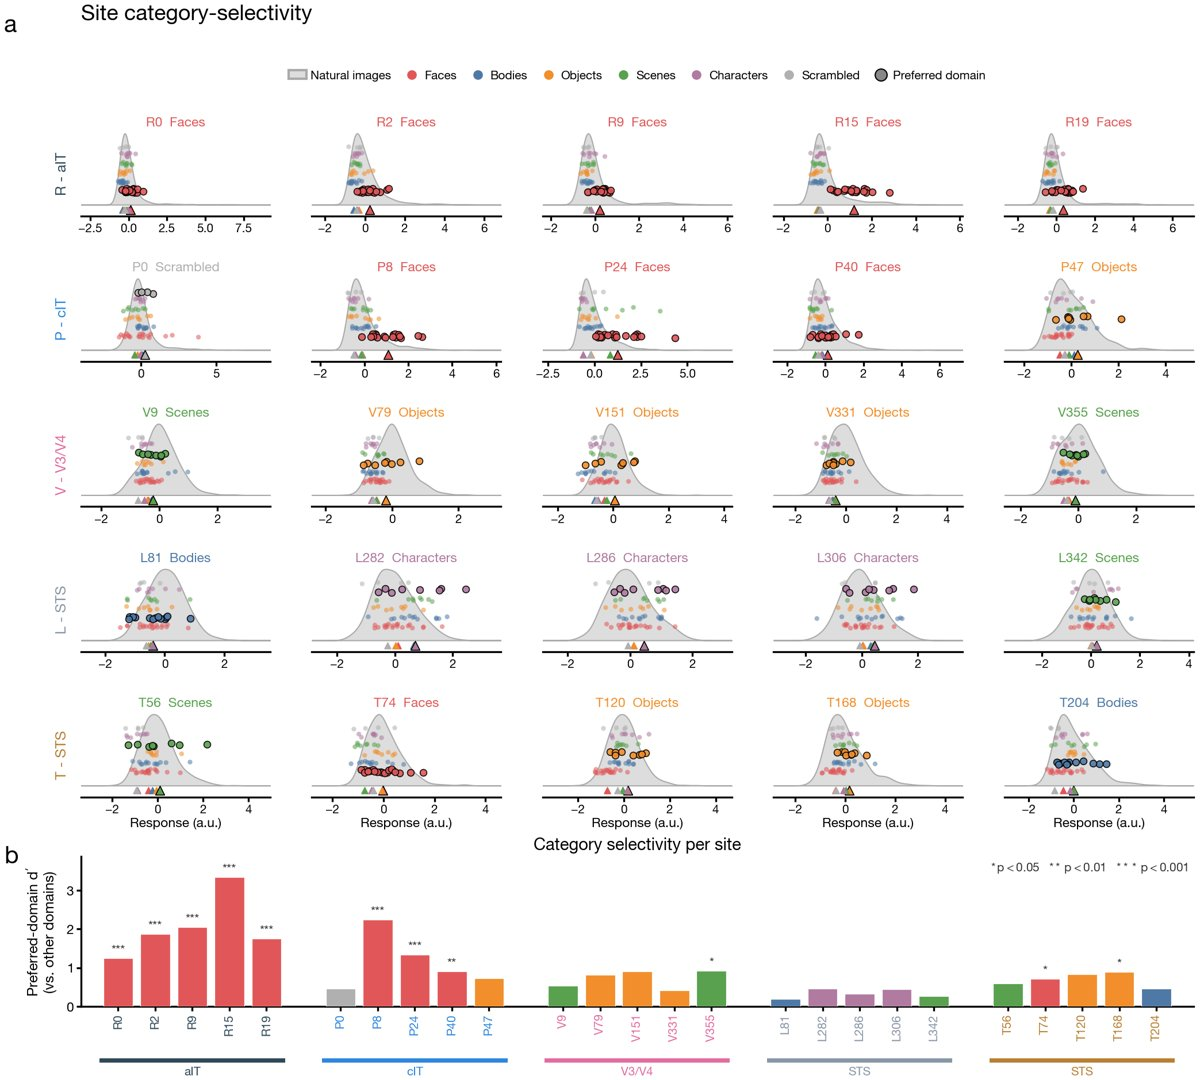

In [15]:
import io
from IPython.display import Image, display
from PIL import Image as PILImage

# A JPEG preview keeps the notebook small; open the PNG for full detail.
print(png)
im = PILImage.open(png).convert("RGB")
im.thumbnail((1200, 1200))
buf = io.BytesIO(); im.save(buf, "JPEG", quality=85, optimize=True)
display(Image(data=buf.getvalue(), format="jpeg", width=900))

**Supplementary Figure S4. Category selectivity of recorded sites.** fLoc category responses of the $n = 25$ recorded sites, shown against each site's calibration-phase natural-image response distribution. (A) In-context response distributions, one panel per site, grouped by animal and area (Monkey R/aIT, P/cIT, V/V3/V4, L/STS, T/STS; $5$ sites each). Gray shading is the kernel density of natural-image responses; jittered dots are the six fLoc category responses (Faces, Bodies, Objects, Scenes, Characters, Scrambled), with triangles marking category means. Each site's preferred domain (largest mean) is highlighted with black-edged markers and named in the panel title. (B) Summary of preferred-domain selectivity across all $25$ sites. Bar height is the preferred-domain $d'$ (preferred category versus all other categories), colored by preferred domain; $x$-tick labels and region brackets are colored by animal. Asterisks denote a Welch $t$-test of preferred versus other categories ($* p < 0.05$, $** p < 0.01$, $*** p < 0.001$). aIT and cIT sites, targeted to face patches, show the strongest and most consistent selectivity, whereas V3/V4 and STS sites are more mixed.